# The coordinates perturbation for investgating the gene-gene co-occurrent robustness

- ***Motivation***:  
  Spatial technologies inherently own the incorrectness of gene spatial coordinations and cell segmentation. The definition of our gene-gene co-occurrence should be largely based on the accurate positional information.
  Therefore, we assay the gene pairs robustness based on different level of perturbations in this notebook

- ***test files***
  - Brain: from Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs as [***brain_transcripts.csv.gz***](https://figshare.com/account/projects/238169/articles/30627677)
  - Lung: from GSM7990543_output-XETG00048__0003817__VUILD102LA__20230308__003731 as [**lung_transcripts.csv.gz***](https://figshare.com/account/projects/238169/articles/30627677)
  

In [1]:
import sys
sys.path.append("/scratch/project_465001820/Spatialformer/data_preprocessing")
from process import KNN_Radius_Graph
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import List, Dict, Tuple
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client
import itertools
from tqdm.auto import tqdm
from dask.distributed import as_completed
# Usage
from typing import Optional, List, Tuple
import pickle
import multiprocessing as mp
from multiprocessing import Pool, Manager, Queue
from functools import partial
import gc

/scratch/project_465001820/miniconda3/envs/spatialformer/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

def get_gco(gene_binary_matrix: np.ndarray, all_genes: List[str]) -> List:
    """
    Get the non-redundance gene pairs from the co-occurrence matrix

    Args:
    gene_binary_matrix: np.ndarray, the binary gene-gene co-occurrence matrix
    all_genes: List. A list with all the gene names in the dataset
    ==========
    Return:
    gene_pair: a single list that contains the paired gene pairs 
    
    """
    all_genes = list(sorted(all_genes))
    
    # Create upper triangle mask (excluding diagonal)
    upper_triangle = np.triu(gene_binary_matrix, k=1)
    
    # Find non-zero positions in upper triangle
    nonzero_rows, nonzero_cols = np.where(upper_triangle != 0)
    nonzero_values = gene_binary_matrix[nonzero_rows, nonzero_cols]
    
    gene_pair = []
    
    for row, col in zip(nonzero_rows, nonzero_cols):
        gene_pair.append([all_genes[row], all_genes[col]])
    return gene_pair
def gaussian_noise(df: pd.DataFrame = None, std: int = 0, iteration: int = 0, sigma: float=0.05) -> pd.DataFrame:
    """
    Add gaussian noise to the transcript spatial coordinates

    Args:
    df: dataframe of the transcripts.csv file
    std: the standard deviation of the perturbation, which indicates the strength of the noise.
    sigma: the 
    ==============================
    Return:
    the perturbed dataframe

    """
    perturb_df = df.copy()
    #0.2 is normal noise, but we want very small as 0.1 in the first 50 steps
    # Sigmas array: first 30 points from 0.01 to 0.1, then 500 points all 0.2
    sigmas = np.concatenate([
        np.linspace(0.01, 0.2, 50),  
        [std] * 2000
    ])
    
    noise_x = np.random.normal(0, sigmas[iteration], perturb_df.shape[0])
    noise_y = np.random.normal(0, sigmas[iteration], perturb_df.shape[0])
    noise_z = np.random.normal(0, sigmas[iteration], perturb_df.shape[0])
    

    # accumulate the noise
    if iteration == 0:
        perturb_df["x_0"] = perturb_df["x"] + noise_x
        perturb_df["y_0"] = perturb_df["y"] + noise_y
        perturb_df["z_0"] = perturb_df["z"] + noise_z
    else:
        perturb_df[f"x_{iteration}"] = perturb_df[f"x_{iteration-1}"] + noise_x
        perturb_df[f"y_{iteration}"] = perturb_df[f"y_{iteration-1}"] + noise_y
        perturb_df[f"z_{iteration}"] = perturb_df[f"z_{iteration-1}"] + noise_z
        #delete the previous columns
        cols_to_delete = [f"x_{iteration-1}", f"y_{iteration-1}", f"z_{iteration-1}"]
        perturb_df = perturb_df.drop(columns=cols_to_delete, errors="ignore")


    #assign the noise back to the original coordinates
    perturb_df["x"] = perturb_df[f"x_{iteration}"]
    perturb_df["y"] = perturb_df[f"y_{iteration}"]
    perturb_df["z"] = perturb_df[f"z_{iteration}"]
    return perturb_df

def metric(gene_pair1: List, gene_pair2: List)-> float:
    """
    evaluation of the robustness

    Args:
    gene_pair1: List, the reference gene pairs that were originally detected by the actual coordinate system
    gene_pair2: List, the gene pairs that were found when the perturbed coordinates were introduced
    ============================
    Return:
    
    """
    
    assert len(gene_pair1) >=1, "The reference gene pairs not found"
    ovlp_pairs = [pair for pair in gene_pair2 if pair in gene_pair1]
    keep_pct = len(ovlp_pairs)/len(gene_pair1)

    return keep_pct
 
def boundary_selection(df: pd.DataFrame, quantile: float = 0.9, frac: float = 0.05):
    """
    Randomly unassign transcripts in the outer boundary (risk zone) of the cytoplasm
    to simulate segmentation leakage.

    Args:
    df (pd.DataFrame): Dataframe containing 'overlaps_nucleus', 'nucleus_distance', and 'cell_id'.
                       Assumes 'nucleus_distance' is normalized (0=center, 1=edge).
    quantile (float): The distance threshold (0.0 to 1.0) defining the start of the risk zone.
                            e.g., 0.9 means the outer 10% of the cell radius.
    frac (float): The fraction of transcripts in the risk zone to "leak" (unassign).
                       e.g., 0.05 means 5% of boundary transcripts are removed.

    Returns:
    pd.DataFrame: The dataframe with simulated segmentation errors.
    """
    
    # 1. Split Data & Create Copies (Prevents SettingWithCopyWarning)
    # Keep nucleus transcripts safe
    df_nucleus = df[df["overlaps_nucleus"] == 1].copy()
    
    # Work on cytoplasm transcripts
    df_cyto = df[df["overlaps_nucleus"] == 0].copy()

    # 2. Define the Risk Zone
    # We use df_cyto for BOTH conditions to ensure index alignment
    quantile_val = df_cyto['nucleus_distance'].quantile(quantile)
    risk_zone_mask = df_cyto['nucleus_distance'] > quantile_val
    
    # 3. Select Candidates to "Leak"
    n_risk = risk_zone_mask.sum()
    
    if n_risk > 0:
        # Generate boolean choices based on the leak_frac argument
        # p=[True_prob, False_prob]
        leak_candidates = np.random.choice(
            [True, False], 
            size=n_risk, 
            p=[frac, 1 - frac]
        )
        
        # Get global indices of the transcripts selected for leakage
        # We look at the subset of df_cyto inside the risk zone, then filter by our random choice
        target_indices = df_cyto[risk_zone_mask].index[leak_candidates]
        
        # 4. Apply the Leakage (Label Swapping/Unassignment)
        df_cyto.loc[target_indices, 'cell_id'] = 'Unassigned' 
     

    # 5. Recombine
    df_selected = pd.concat([df_nucleus, df_cyto]).sort_index()
    
    return df_selected
def run_for_sc(df: pd.DataFrame, raw_df: pd.DataFrame, cell_id: str, all_genes: List, std: int, iteration: int, boundary_noise: bool, quantile: float, frac: float, clustering: bool, radius: int) -> float:
    """
    The main function for a single cell to get the gene robustness

    Args:
    df: pd.DataFrame. The filtered transcript dataframe with all the transcripts' info
    raw_df: pd.DataFrame. The raw transcript dataframe with all the transcripts' info
    cell_id: str. The cell barcode id.
    all_genes: List. All the genes detected in the datasets.
    std: int. The standard deviation of the noise that is introduced to the transcripts.
    iteration: int. The nth iteration of the perturbation. The perturbation should be accumulated.
    boundary_noise: bool. Whether considering the uncertainty of the cell boundary
    quantile: float. The quantile to define the unvertainty boundary transcripts
    frac: float. fraction of transcripts near to the cell boundary
    clustering: bool. Whether clustering the transcripts to pick paired genes.
    radius: int. The radius of the transcript neighbors
    ==========================
    Return:
    The percentage of the genes remains.
    """

    # getting the reference gene pairs for comparing
    data_graph = KNN_Radius_Graph(radius=radius, dataset=raw_df, is_3D=True, cell_ID=cell_id, ref_gene=all_genes, clustering = clustering)
    gene_binary_matrix, gene_freq_matrix, trans_matrix = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    ref_pair_num = int(np.sum(np.triu(gene_binary_matrix, k=1)))
    ref_gene_pairs = get_gco(gene_binary_matrix, all_genes)
    
    if boundary_noise:
        
        #introducing the noise
        df_noise = gaussian_noise(df = df, std = std, iteration = iteration)
        # get the subset of the dataframe according to the cell boundary
        # print("before:", df_noise.shape)
        df_noise_bd = boundary_selection(df_noise, quantile, frac)
        # print("df_noise", df_noise.columns)
        # print("after:",df_noise_bd.shape)
        data_graph = KNN_Radius_Graph(radius=radius, dataset=df_noise_bd, is_3D=True, cell_ID=cell_id, ref_gene=all_genes)
        # print("data_graph:", data_graph)

    else:
        #introducing the noise
        df_noise = gaussian_noise(df = df, std = std, iteration = iteration)
   

        data_graph = KNN_Radius_Graph(radius=radius, dataset=df_noise, is_3D=True, cell_ID=cell_id, ref_gene=all_genes)
    gene_binary_matrix_n, gene_freq_matrix_n, trans_matrix_n = data_graph.get_gene_matrix(pair_threshold=3, self_threshold=3, plot=False)
    # print("1")
    ptb_pair_num = int(np.sum(np.triu(gene_binary_matrix, k=1)))
    ptb_gene_pairs = get_gco(gene_binary_matrix_n, all_genes)
    # print("2")
    # print("ref pairs:", ref_gene_pairs)
    # print("ptb pairs:", ptb_gene_pairs)
    pct = metric(ref_gene_pairs, ptb_gene_pairs)
    # print("3")
    # print("pct:", pct)
    # print("df_noise:", df_noise)
    
    return pct, ref_pair_num, df_noise

In [3]:
# ----------------------------
# Pre-calculate noise transformations
# ----------------------------
def generate_all_perturbations(
    raw_df: pd.DataFrame,
    cell_ids: List[str],
    iter_num: int,
    std: int,
    boundary_noise: bool = False,
    quantile: float = 0.8,
    frac: float = 0.8,
    sequential: float = False
) -> Dict[Tuple[str, int], pd.DataFrame]:
    """
    Pre-generate ALL perturbed dataframes for all cells and all iterations
    
    Returns:
        Dict[(cell_id, iteration)] = perturbed_df
    """
    print(f"Pre-generating {len(cell_ids) * iter_num} perturbed dataframes...")
    
    # Group by cell
    cell_groups = {cid: group.reset_index(drop=True) 
                   for cid, group in raw_df.groupby("cell_id") 
                   if cid in cell_ids}
    
    perturbed_data = {}
    
    for cid in tqdm(cell_ids, desc="Generating perturbations"):
        if cid not in cell_groups:
            continue
            
        cell_df = cell_groups[cid]
        current_df = cell_df.copy()
        
        # Generate perturbations for all iterations
        for iteration in range(iter_num):
            
            if not sequential:
                if boundary_noise:
                    df_noise = boundary_selection(current_df, quantile, frac)
                else:
                    # Apply cumulative noise
                    df_noise = gaussian_noise(df=current_df, std=std, iteration=iteration)
                    # Update current state for next iteration (cumulative)
                    current_df = df_noise
            else:
                df_noise = boundary_selection(current_df, quantile, frac)
                df_noise = gaussian_noise(df=df_noise, std=std, iteration=iteration)
                # Update current state for next iteration (cumulative)
                current_df = df_noise
            
            # Store this perturbation
            perturbed_data[(cid, iteration)] = df_noise.copy()
            
            
    
    print(f"Generated {len(perturbed_data)} perturbed dataframes")
    return perturbed_data
# ----------------------------
# Process single task
# ----------------------------

def run_for_sc_precomputed(
    cell_id: str,
    iteration: int,
    raw_df: pd.DataFrame,
    perturbed_df: pd.DataFrame,
    all_genes: List[str],
    clustering: bool,
    radius: int
) -> Tuple[float, int]:
    """
    Process a single cell at a single iteration with pre-computed perturbation
    
    Args:
        raw_df: Original reference dataframe for this cell
        perturbed_df: Pre-computed perturbed dataframe
    """
    # Get reference gene pairs (from original)
    data_graph = KNN_Radius_Graph(
        radius=radius, 
        dataset=raw_df, 
        is_3D=True, 
        cell_ID=cell_id, 
        ref_gene=all_genes, 
        clustering=clustering
    )
    gene_binary_matrix, _, _ = data_graph.get_gene_matrix(
        pair_threshold=3, 
        self_threshold=3, 
        plot=False
    )
    ref_pair_num = int(np.sum(np.triu(gene_binary_matrix, k=1)))
    ref_gene_pairs = get_gco(gene_binary_matrix, all_genes)
    
    # Get perturbed gene pairs
    data_graph_ptb = KNN_Radius_Graph(
        radius=radius, 
        dataset=perturbed_df, 
        is_3D=True, 
        cell_ID=cell_id, 
        ref_gene=all_genes,
        clustering=clustering
    )
    gene_binary_matrix_n, _, _ = data_graph_ptb.get_gene_matrix(
        pair_threshold=3, 
        self_threshold=3, 
        plot=False
    )
    ptb_pair_num = int(np.sum(np.triu(gene_binary_matrix_n, k=1)))
    ptb_gene_pairs = get_gco(gene_binary_matrix_n, all_genes)
    
    # Calculate metric

    pct = metric(ref_gene_pairs, ptb_gene_pairs)
    
    return pct, ref_pair_num


def run_for_sc_precomputed_wrapper(args):
    """Wrapper for multiprocessing"""
    try:
        cell_id, iteration, raw_df, perturbed_df, all_genes, clustering, radius = args
        
        pct, ref_pair_num = run_for_sc_precomputed(
            cell_id=cell_id,
            iteration=iteration,
            raw_df=raw_df,
            perturbed_df=perturbed_df,
            all_genes=all_genes,
            clustering=clustering,
            radius=radius
        )
        
        # Clean up
        del raw_df, perturbed_df
        gc.collect()
        
        return (cell_id, iteration, pct, ref_pair_num)
        
    except Exception as e:
        pass
        # print(f"Error processing cell {args[0]} iteration {args[1]}: {e}")
        # import traceback
        # traceback.print_exc()
        return None


# ----------------------------
# Optimized Perturb class
# ----------------------------

class Perturb:
    def __init__(self, std: int = 20):
        self.std = std
        
    def qc(self, df) -> pd.DataFrame:
        """Run QC and return filtered dataframe."""
        rename_map = {}
        if "x_location" in df.columns:
            rename_map["x_location"] = "x"
        if "y_location" in df.columns:
            rename_map["y_location"] = "y"
        if "z_location" in df.columns:
            rename_map["z_location"] = "z"
        if "feature_name" in df.columns:
            rename_map["feature_name"] = "gene"
        if rename_map:
            df = df.rename(columns=rename_map)
        
        df_flt1 = df[
            ~(df["gene"].str.startswith("Neg") |
              df["gene"].str.startswith("BLANK") |
              df["gene"].str.startswith("Unassigned"))
        ].copy()

        vc = df_flt1["cell_id"].value_counts()
        if "UNASSIGNED" in vc.index:
            vc = vc.drop("UNASSIGNED")
        good_cells = vc[vc >= 30].index
        df_flt2 = df_flt1[df_flt1["cell_id"].isin(good_cells)].reset_index(drop=True)
        return df_flt2

    def run_all_precomputed(
        self,
        raw_df: pd.DataFrame,
        perturbed_data: Dict[Tuple[str, int], pd.DataFrame],
        all_genes: List[str],
        cell_ids: List[str],
        iter_num: int,
        n_processes: int = None,
        chunk_size: int = 10,
        clustering: bool = True,
        radius: int = 5
    ) -> Tuple[Dict, Dict]:
        """
        Process all pre-computed perturbations in parallel
        """
        if n_processes is None:
            n_processes = max(1, os.cpu_count() - 2)
        
        # Get raw data for each cell
        raw_cell_groups = {cid: group.reset_index(drop=True) 
                          for cid, group in raw_df.groupby("cell_id") 
                          if cid in cell_ids}
        
        # ✅ Generate ALL tasks upfront
        all_tasks = []
        for cid in cell_ids:
            if cid not in raw_cell_groups:
                continue
                
            raw_cell_df = raw_cell_groups[cid]
            
            for iteration in range(iter_num):
                key = (cid, iteration)
                if key not in perturbed_data:
                    continue
                
                perturbed_df = perturbed_data[key]
                
                all_tasks.append((
                    cid,
                    iteration,
                    raw_cell_df,
                    perturbed_df,
                    all_genes,
                    clustering,
                    radius
                ))
        
        total_tasks = len(all_tasks)
        print(f"Processing {total_tasks} tasks with {n_processes} workers...")
        
        # ✅ Process ALL tasks in parallel
        all_results = []
        failed_num = 0
        with Pool(processes=n_processes) as pool:
            for result in tqdm(
                pool.imap_unordered(run_for_sc_precomputed_wrapper, all_tasks, chunksize=chunk_size),
                total=total_tasks,
                desc="Processing all perturbations"
            ):
                if result is not None:
                    all_results.append(result)
                
                    
        
        # ✅ Organize results by iteration
        results = {i: [] for i in range(iter_num)}
        all_nums = {i: [] for i in range(iter_num)}
        
        for cell_id, iteration, pct, ref_pair_num in all_results:
            results[iteration].append(pct)
            all_nums[iteration].append(ref_pair_num)
        
        print(f"Successfully processed {len(all_results)}/{total_tasks} tasks")
        
        return results, all_nums


# ----------------------------
# Optimized pipeline
# ----------------------------

def run_optimized_pipeline_precomputed(
    raw_df,
    iter_num: int = 100,
    limit_cells: int = 500,
    std: int = 1,
    boundary_noise: bool = False,
    quantile: float = 0.8,
    frac: float = 0.8,
    clustering: bool = True,
    chunk_size: int = 10,
    n_processes: int = None,
    radius: int = 5
):
    """
    Optimized pipeline:
    1. Pre-generate ALL perturbations (sequential, fast)
    2. Process ALL tasks in parallel (parallel, slow part)
    """
    if n_processes is None:
        n_processes = max(1, os.cpu_count() - 2)
    
    print(f"Using {n_processes} worker processes with chunk size {chunk_size}")
    
    p = Perturb(std=std)
    raw_df = p.qc(raw_df)
    
    # Get cell IDs
    all_cell_ids = list(raw_df["cell_id"].unique())
    if limit_cells:
        all_cell_ids = all_cell_ids[:limit_cells]
    
    all_genes = raw_df["gene"].unique().tolist()
    
    print(f"Processing {len(all_cell_ids)} cells for {iter_num} iterations")
    print(f"Total tasks: {len(all_cell_ids) * iter_num}")
    
    # ✅ STEP 1: Pre-generate all perturbations (fast, sequential)
    print("\n" + "="*60)
    print("STEP 1: Generating all perturbations")
    print("="*60)
    
    perturbed_data = generate_all_perturbations(
        raw_df=raw_df,
        cell_ids=all_cell_ids,
        iter_num=iter_num,
        std=std,
        boundary_noise=boundary_noise,
        quantile=quantile,
        frac=frac
    )
    
    # ✅ STEP 2: Process all in parallel (slow, but parallelized)
    print("\n" + "="*60)
    print("STEP 2: Processing all gene pairs in parallel")
    print("="*60)
    
    results, all_nums = p.run_all_precomputed(
        raw_df=raw_df,
        perturbed_data=perturbed_data,
        all_genes=all_genes,
        cell_ids=all_cell_ids,
        iter_num=iter_num,
        n_processes=n_processes,
        chunk_size=chunk_size,
        clustering=clustering,
        radius=radius
    )
    
    # Get final perturbed dataframe
    final_dfs = []
    for cid in all_cell_ids:
        key = (cid, iter_num - 1)
        if key in perturbed_data:
            final_dfs.append(perturbed_data[key])
    
    final_df = pd.concat(final_dfs, axis=0, ignore_index=True) if final_dfs else pd.DataFrame()
    
    # Clean up
    del perturbed_data
    gc.collect()
    
    return results, all_nums, final_df


# ----------------------------
# Batched version for memory efficiency
# ----------------------------

def run_optimized_pipeline_precomputed_batched(
    raw_df,
    iter_num: int = 100,
    limit_cells: int = 500,
    std: int = 1,
    boundary_noise: bool = False,
    quantile: float = 0.8,
    frac: float = 0.8,
    clustering: bool = True,
    chunk_size: int = 10,
    n_processes: int = None,
    radius: int = 5,
    batch_size: int = 100,  # Process 100 cells at a time
    sequential:float = False
):
    """
    Memory-efficient version: Process cells in batches
    """
    if n_processes is None:
        n_processes = max(1, os.cpu_count() - 2)
    
    p = Perturb(std=std)
    raw_df = p.qc(raw_df)
    
    all_cell_ids = list(raw_df["cell_id"].unique())
    if limit_cells:
        all_cell_ids = all_cell_ids[:limit_cells]
    
    all_genes = raw_df["gene"].unique().tolist()
    
    print(f"Processing {len(all_cell_ids)} cells in batches of {batch_size}")
    
    # Store all results
    all_results = {i: [] for i in range(iter_num)}
    all_nums_combined = {i: [] for i in range(iter_num)}
    
    # Process in batches
    for batch_start in range(0, len(all_cell_ids), batch_size):
        batch_end = min(batch_start + batch_size, len(all_cell_ids))
        batch_cells = all_cell_ids[batch_start:batch_end]
        
        print(f"\n{'='*60}")
        print(f"Batch {batch_start//batch_size + 1}: Cells {batch_start}-{batch_end-1}")
        print(f"{'='*60}")
        
        # Filter raw_df for this batch
        batch_raw_df = raw_df[raw_df['cell_id'].isin(batch_cells)].reset_index(drop=True)
        
        # Generate perturbations for this batch
        perturbed_data = generate_all_perturbations(
            raw_df=batch_raw_df,
            cell_ids=batch_cells,
            iter_num=iter_num,
            std=std,
            boundary_noise=boundary_noise,
            quantile=quantile,
            frac=frac,
            sequential=sequential
        )
        
        # Process this batch
        results, all_nums = p.run_all_precomputed(
            raw_df=batch_raw_df,
            perturbed_data=perturbed_data,
            all_genes=all_genes,
            cell_ids=batch_cells,
            iter_num=iter_num,
            n_processes=n_processes,
            chunk_size=chunk_size,
            clustering=clustering,
            radius=radius
        )
        
        # Combine results
        for i in range(iter_num):
            all_results[i].extend(results[i])
            all_nums_combined[i].extend(all_nums[i])
        
        # Clean up
        del perturbed_data, results, all_nums, batch_raw_df
        gc.collect()
    
    return all_results, all_nums_combined

In [4]:
sigmas = np.concatenate([
            np.linspace(0.01, 0.2, 50),  
            [0.2] * 2000
        ])
    
std_x = 0
rsl = []
for iteration in range(500):
    std_x = np.sqrt(std_x**2 + sigmas[iteration]**2)
    rsl.append(std_x)
print(rsl)

[0.01, 0.017105157769632867, 0.024654210001617, 0.032799416904438064, 0.04155204280847916, 0.05089412944039038, 0.06080125823464061, 0.07124875324979481, 0.08221349478966959, 0.09367435862812105, 0.10561219560286733, 0.11800966365670305, 0.1308510253576608, 0.144121951923498, 0.1578093472753232, 0.17190119494830858, 0.1863864266561525, 0.20125480998543624, 0.2164968524721834, 0.23210371950864106, 0.24806716385740485, 0.26437946489416675, 0.28103337601428385, 0.2980220789083721, 0.3153391436377731, 0.33297849362657933, 0.3509343748388938, 0.369201328533977, 0.3877741670930685, 0.4066479524942983, 0.4258179770797982, 0.44527974631475675, 0.46502896328405674, 0.48506151471013925, 0.5053734583073354, 0.5259610113142804, 0.5468205400681287, 0.5679485505028831, 0.5893416794698557, 0.6109966867915932, 0.632910447971923, 0.6550799474944486, 0.6775022726501102, 0.7001746078415412, 0.7230942293180996, 0.7462585003007586, 0.7696648664606501, 0.7933108517190643, 0.8171940543402038, 0.8413121432910

In [15]:
def plot_robustness_seaborn(*pct_dicts:  Dict[int, list], title="Robustness Analysis", filename="demo", 
                           std:  float=0.2, boundary_noise: float=False, smooth:float=False, zoom:bool=False):
    """
    Plot robustness using Seaborn for better styling

    Args:
        *pct_dicts: Dicts.  Each dict's keys are iterations (int) and values are lists (pct for each cell).
        title: str. Title for plot.
        filename: str.  Filename to save plot.
        std: float. standard deviation for each iteration
        boundary_noise: float. whether to introduce the boundary uncertainty
        smooth: float. whether to apply smoothing
        zoom: bool. whether to add zoomed inset for 0-30nm range
    Return:
        A plot for visualization
    """
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from matplotlib.patches import Rectangle
    
    colors = ["#3575A2", "#3575A2", "#E1822B", "#E1822B","#EB5354", "#EB5354"]
    labels = ["r=3; Louvain (w)", "r=3; Louvain (w/o)", "r=4; Louvain (w)", "r=4; Louvain (w/o)", "r=5; Louvain (w)", "r=5; Louvain (w/o)"]
    linestyles = ["-", "--"]*10
    if len(pct_dicts) == 3:
        labels = ["low", "median", "high"]
        colors = ["#EB5354", "#00B8B2","#343795"]
        linestyles = ["-"]*10
    
    # Create figure and main axis
    fig, ax = plt.subplots(figsize=(10, 6))

    #get the number of cells
    cell_num = len(pct_dicts[0][1])
    #define the std values
    sigmas = np.concatenate([
            np.linspace(0.01, 0.2, 50),  
            [std] * 2000
        ])
    
    # Store stats for each dataset (needed for zoom plot)
    all_stats = []
    
    for i, pct_dict in enumerate(pct_dicts):
        # Convert dictionary to DataFrame
        records = []
        std_x = 0
        if boundary_noise:
            records.append({"Iterations": 0, "Re_occurrence_rate": 1})
        else:
            records. append({"Std": 0, "Re_occurrence_rate": 1})
        for iteration, values in pct_dict.items():
            std_x = np.sqrt(std_x**2 + sigmas[iteration]**2)
            for val in values:
                if boundary_noise:
                    records.append({"Iterations": iteration+1, "Re_occurrence_rate": val})
                else: 
                    records.append({"Std": std_x, "Re_occurrence_rate": val})
        df = pd.DataFrame(records)
        if boundary_noise:
            stats = df.groupby("Iterations")["Re_occurrence_rate"]. agg(["mean", "std", "min", "max"]).reset_index()
        else:
            # Compute mean and std per iteration
            stats = df.groupby("Std")["Re_occurrence_rate"].agg(["mean", "std", "min", "max"]).reset_index()

        if smooth:
            # Smooth the mean
            stats['smoothed_mean'] = stats['mean'].rolling(
                window=5, 
                min_periods=1, 
                center=True
            ).mean()
            
            # Smooth the std
            stats['smoothed_std'] = stats['std'].rolling(
                window=5, 
                min_periods=1, 
                center=True
            ).mean()
            
            value_col = "smoothed_mean"
            std_col = "smoothed_std"
        else:
            value_col = "mean"
            std_col = "std"
        
        # Store stats for zoom inset
        all_stats.append((stats, value_col, std_col))

        # Plot on main axis
        if boundary_noise:
            x_col = "Iterations"
        else:
            x_col = "Std"
        
        # Plot shaded band (mean ± std)
        ax.fill_between(
            stats[x_col],
            stats[value_col] - stats[std_col],
            stats[value_col] + stats[std_col],
            alpha=0.25,
            color=colors[i]
        )
        
        # Plot mean line
        sns.lineplot(
            data=stats,
            x=x_col,
            y=value_col,
            marker=None,
            linewidth=2.5,
            markersize=8,
            color=colors[i],
            label=labels[i],
            linestyle=linestyles[i],
            ax=ax
        )

    # Main axis labeling
    if boundary_noise:
        ax.set_xlabel("Iterations (th)", fontsize=20, fontweight="bold")
        x_col = "Iterations"
    else:
        ax.set_xlabel("Std (µm)", fontsize=20, fontweight="bold")
        x_col = "Std"
    
    ax.set_ylabel("Re-occurrence (%)", fontsize=20, fontweight="bold")
    ax.tick_params(axis='both', labelsize=20)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    
    # Add zoom inset if requested
    if zoom and not boundary_noise:  # Only for Std plots
        # Create inset axis
        ax_inset = inset_axes(
            ax,
            width="65%",      # Width of inset
            height="65%",     # Height of inset
            bbox_to_anchor=(1.05, 0.0, 0.4, 0.4),  # (x, y, width, height)
            bbox_transform=ax.transAxes,
            loc='lower left',  # Anchor point of the inset
            borderpad=2.5     # Padding from edge
        )
        
        # Plot data in inset for 0-30nm (0-0.03 µm) range
        for i, (stats, value_col, std_col) in enumerate(all_stats):
            # Filter data for zoom range
            zoom_stats = stats[stats["Std"] <= 0.05]. copy()
            
            if len(zoom_stats) > 0:
                # Plot shaded band
                ax_inset.fill_between(
                    zoom_stats["Std"],
                    zoom_stats[value_col] - zoom_stats[std_col],
                    zoom_stats[value_col] + zoom_stats[std_col],
                    alpha=0.25,
                    color=colors[i]
                )
                
                # Plot mean line
                ax_inset.plot(
                    zoom_stats["Std"],
                    zoom_stats["mean"],
                    linewidth=2,
                    color=colors[i],
                    linestyle=linestyles[i]
                )
        
        # Inset styling
        ax_inset.set_xlim(0, 0.04)  # 0-30 nm in µm
        ax_inset.set_ylim(0, 1.1)   # Match main plot y-limits
        ax_inset.set_xlabel('0-40 nm', fontsize=10, fontweight='bold')
        ax_inset.set_ylabel('Re-occurrence (%)', fontsize=10)
        ax_inset.tick_params(labelsize=9)
        ax_inset.grid(True, alpha=0.3, linewidth=0.5)
        ax_inset.set_title('Zoom: 0-40 nm', fontsize=9, fontweight='bold')
        
        # Highlight zoomed region on main plot
        y_min, y_max = ax.get_ylim()
        zoom_box = Rectangle(
            (0, y_min),
            0.03,  # width:  30 nm = 0.03 µm
            y_max - y_min,
            linewidth=1.5,
            edgecolor='gray',
            facecolor='none',
            linestyle='--',
            alpha=0.6
        )
        ax.add_patch(zoom_box)
        
        # Add border to inset
        for spine in ax_inset.spines.values():
            spine. set_edgecolor('gray')
            spine.set_linewidth(1.5)
    
    plt.tight_layout()
    plt.savefig(magic_path("figures", filename), dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
current_path = "/scratch/project_465001820/Spatialformer/downstream/Coordinate_perturbation"
magic_path = lambda *x: os.path.join(os.path.abspath(current_path), *x)

# Run for the Lung dataset

In [7]:
lung_annot_3D_tx = pd.read_csv(magic_path("data", "lung_transcripts.csv.gz"), compression='gzip') 
lung_annot_3D_tx

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance
0,281492156579843,UNASSIGNED,0,UnassignedCodeword_0195,91.884190,908.14520,17.058058,5.573087,V14,642.50250
1,281492156581318,UNASSIGNED,0,COL1A1,30.579700,938.88513,14.035028,21.957850,V14,686.69037
2,281492156581319,UNASSIGNED,0,COL1A1,31.221127,921.47034,13.955322,40.000000,V14,696.42316
3,281492156581355,UNASSIGNED,0,LYZ,89.091270,985.57470,14.136600,11.256810,V14,611.95890
4,281492156581391,UNASSIGNED,0,LYZ,112.088806,974.25800,14.054309,11.206035,V14,600.06320
...,...,...,...,...,...,...,...,...,...,...
9165732,281586645934355,UNASSIGNED,0,TREM2,3582.961000,4343.49900,22.289114,40.000000,Y19,586.41260
9165733,281586645934356,UNASSIGNED,0,CD68,3584.072300,4346.15900,21.291933,40.000000,Y19,589.26117
9165734,281586645934365,UNASSIGNED,0,COL1A2,3603.561300,4331.70700,21.196983,40.000000,Y19,580.32140
9165735,281586645934375,UNASSIGNED,0,COL1A2,3613.133500,4282.03860,21.222462,40.000000,Y19,535.72560


- ***running parameters***: radius=[5,4,3]; std=0.01; iter_num=100
-  ***Objective***: to simulate the real case of the 30nm accuracy for Xenium

In [30]:
all_results1_bd, all_nums_combined1_bd = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100  # Process 100 cells at a time
    )
all_results2_bd, all_nums_combined2_bd = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.7,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100  # Process 100 cells at a time
    )
all_results3_bd, all_nums_combined3_bd = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.5,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100  # Process 100 cells at a time
    )

Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:20<00:00,  1.02s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [24:59<00:00,  6.67it/s] 


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


...

Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:21<00:00,  1.07s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [24:30<00:00,  6.80it/s] 


Successfully processed 10000/10000 tasks


In [31]:
pickle.dump(all_results1_bd, open(magic_path("data", "lung_results_bd_noise_09_c_5.pkl"), "wb"))
pickle.dump(all_results2_bd, open(magic_path("data", "lung_results_bd_noise_07_c_5.pkl"), "wb"))
pickle.dump(all_results3_bd, open(magic_path("data", "lung_results_bd_noise_05_c_5.pkl"), "wb"))

In [8]:
all_results1_bd = pickle.load(open(magic_path("data", "lung_results_bd_noise_09_c_5.pkl"), "rb"))
all_results2_bd = pickle.load(open(magic_path("data", "lung_results_bd_noise_07_c_5.pkl"), "rb"))
all_results3_bd = pickle.load(open(magic_path("data", "lung_results_bd_noise_05_c_5.pkl"), "rb"))

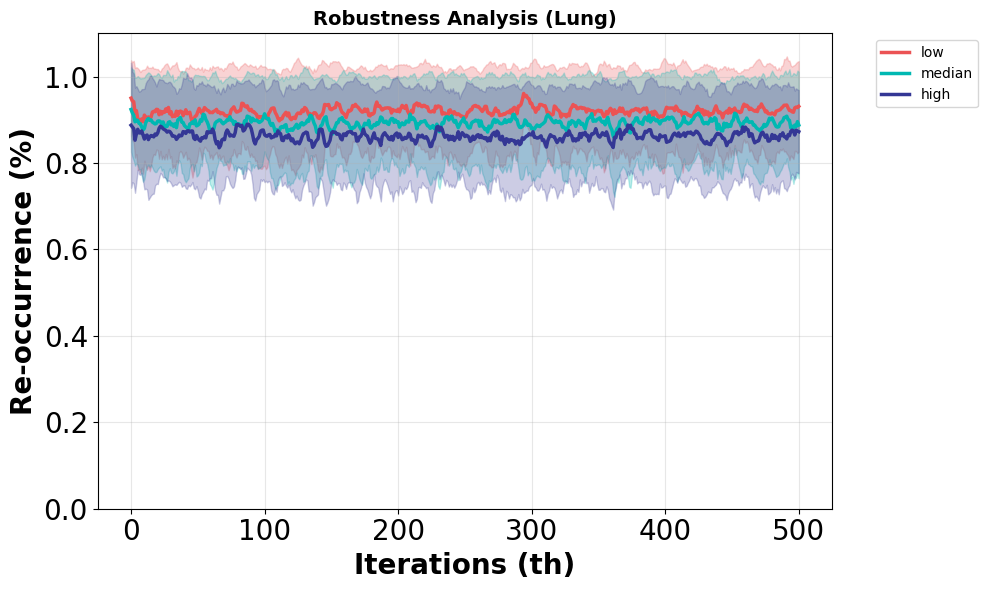

In [9]:
plot_robustness_seaborn(all_results1_bd, all_results2_bd, all_results3_bd,
                        title="Robustness Analysis (Lung)", filename="lung_perturbation_bd_noise", std=0.2, boundary_noise=True, smooth=True)

In [9]:
all_results1, all_nums_combined1 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 3,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results2, all_nums_combined2 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 3,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [04:27<00:00, 37.44it/s]


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:40<00:00,  2.04s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [02:48<00:00, 59.18it/s]


Successfully processed 10000/10000 tasks


In [14]:
import pickle

pickle.dump(all_results1, open(magic_path("data", "lung_results_bd_noise_c_3.pkl"), "wb"))
pickle.dump(all_results2, open(magic_path("data", "lung_results_bd_noise_nc_3.pkl"), "wb"))

In [15]:
all_results3, all_nums_combined3 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 4,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results4, all_nums_combined4 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 4,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [06:27<00:00, 25.79it/s]


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.06s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [03:17<00:00, 50.66it/s]


Successfully processed 10000/10000 tasks


In [16]:
pickle.dump(all_results3, open(magic_path("data", "lung_results_bd_noise_c_4.pkl"), "wb"))
pickle.dump(all_results4, open(magic_path("data", "lung_results_bd_noise_nc_4.pkl"), "wb"))

In [19]:
all_results5, all_nums_combined5 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results6, all_nums_combined6 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.06s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [08:34<00:00, 19.45it/s]


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:40<00:00,  2.02s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [03:48<00:00, 43.74it/s]


Successfully processed 10000/10000 tasks


In [20]:
pickle.dump(all_results5, open(magic_path("data", "lung_results_bd_noise_c_5.pkl"), "wb"))
pickle.dump(all_results6, open(magic_path("data", "lung_results_bd_noise_nc_5.pkl"), "wb"))

In [6]:
# loading the experiment 1 data
all_results1 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_3.pkl"), "rb"))
all_results2 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_3.pkl"), "rb"))
all_results3 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_4.pkl"), "rb"))
all_results4 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_4.pkl"), "rb"))
all_results5 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_5.pkl"), "rb"))
all_results6 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_5.pkl"), "rb"))

/tmp/ipykernel_102318/3163956145.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


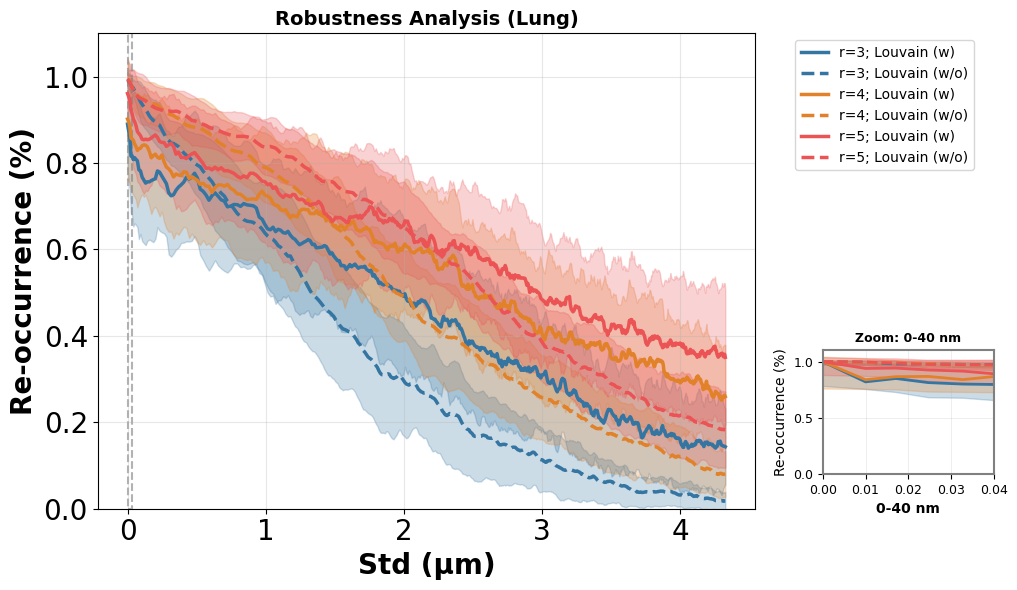

In [16]:
plot_robustness_seaborn(all_results1, all_results2,
                        all_results3, all_results4,
                        all_results5, all_results6,
                        title="Robustness Analysis (Lung)", filename="lung_perturbation_bd_noise_sequential", std=0.2, boundary_noise=False, smooth=True, zoom=True)

In [32]:
all_results7, all_nums_combined7 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 3,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results8, all_nums_combined8 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 3,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations:  90%|█████████ | 18/20 [00:37<00:04,  2.06s/it]

Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.07s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [11:55<00:00, 13.98it/s] 


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [07:46<00:00, 21.45it/s] 


Successfully processed 10000/10000 tasks


In [33]:
pickle.dump(all_results7, open(magic_path("data", "lung_results_nbd_noise_c_3.pkl"), "wb"))
pickle.dump(all_results8, open(magic_path("data", "lung_results_nbd_noise_nc_3.pkl"), "wb"))

In [34]:
all_results9, all_nums_combined9 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 4,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results10, all_nums_combined10 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 4,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations:   0%|          | 0/20 [00:00<?, ?it/s]

Generating perturbations: 100%|██████████| 20/20 [00:41<00:00,  2.08s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [15:34<00:00, 10.70it/s] 


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:36<00:00,  1.84s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [07:59<00:00, 20.84it/s]


Successfully processed 10000/10000 tasks


In [35]:
pickle.dump(all_results9, open(magic_path("data", "lung_results_nbd_noise_c_4.pkl"), "wb"))
pickle.dump(all_results10, open(magic_path("data", "lung_results_nbd_noise_nc_4.pkl"), "wb"))

In [36]:
all_results11, all_nums_combined11 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )
all_results12, all_nums_combined12 = run_optimized_pipeline_precomputed_batched(
    lung_annot_3D_tx,
    iter_num = 500,
    limit_cells = 20,
    std = 0.2,
    boundary_noise = False,
    quantile = 0.9,
    frac = 0.1,
    clustering = False,
    chunk_size = 10,
    n_processes = None,
    radius = 5,
    batch_size = 100,  # Process 100 cells at a time
    sequential = True
    )


Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations:  95%|█████████▌| 19/20 [00:34<00:01,  1.81s/it]

Generating perturbations: 100%|██████████| 20/20 [00:36<00:00,  1.82s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [19:45<00:00,  8.44it/s] 


Successfully processed 10000/10000 tasks
Processing 20 cells in batches of 100

Batch 1: Cells 0-19
Pre-generating 10000 perturbed dataframes...


Generating perturbations: 100%|██████████| 20/20 [00:36<00:00,  1.83s/it]

Generated 10000 perturbed dataframes
Processing 10000 tasks with 126 workers...



Processing all perturbations: 100%|██████████| 10000/10000 [09:06<00:00, 18.29it/s]


Successfully processed 10000/10000 tasks


In [37]:
pickle.dump(all_results11, open(magic_path("data", "lung_results_nbd_noise_c_5.pkl"), "wb"))
pickle.dump(all_results12, open(magic_path("data", "lung_results_nbd_noise_nc_5.pkl"), "wb"))

In [17]:
all_results7 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_3.pkl"), "rb"))
all_results8 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_3.pkl"), "rb"))
all_results9 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_4.pkl"), "rb"))
all_results10 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_4.pkl"), "rb"))
all_results11 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_5.pkl"), "rb"))
all_results12 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_5.pkl"), "rb"))

/tmp/ipykernel_102318/3163956145.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


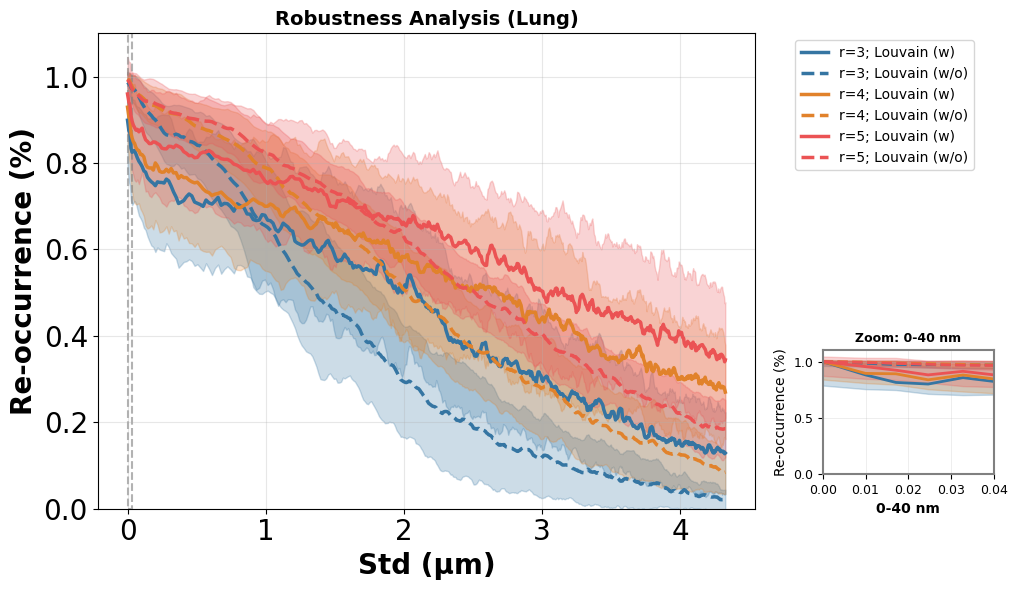

In [18]:
plot_robustness_seaborn(all_results7, all_results8,
                        all_results9, all_results10,
                        all_results11, all_results12,
                        title="Robustness Analysis (Lung)", filename="lung_perturbation_nbd_noise_sequential", std=0.2, boundary_noise=False, smooth=True, zoom=True)

# Run for Brain data

- ***running parameters***: radius=[5,4,3]; std=0.02; iter_num=1500
-  ***Objective***: to simulate the real case of the Xenium

In [ ]:
brain_annot_3D_tx = pd.read_csv(magic_path("data", "brain_transcripts.csv.gz"), compression='gzip') 

In [ ]:
all_results1, all_nums_combined1 = run_optimized_pipeline_precomputed_batched(
    brain_annot_3D_tx,
    iter_num = 1500,
    limit_cells = 200,
    std = 0.2,
    boundary_noise = True,
    quantile = 0.9,
    frac = 0.8,
    clustering = True,
    chunk_size = 10,
    n_processes = None,
    radius = 3,
    batch_size = 100  # Process 100 cells at a time
    )

In [ ]:
plot_robustness_seaborn(all_results7, all_results8, 
                        all_results9, all_results10, 
                        all_results11, all_results12, 
                        title="Robustness Analysis (Brain)", filename="demo", std=0.2)

# Visualization of the plots

In [ ]:
plot_robustness_seaborn(all_results_1, all_results_2,
                        title="Robustness Analysis",
                       filename="lung_results_nbd_noise", std=0.01)

In [ ]:
all_results_1

In [ ]:
lung_annot_3D_tx = pd.read_csv(magic_path("data", "lung_transcripts.csv.gz"), compression='gzip') 
# Run the optimized pipeline
keep_pct_1, pair_num_1, _ = run_optimized_pipeline(
    raw_df=lung_annot_3D_tx,
    iter_num=200,
    limit_cells=1,
    std=0.2,                             
    boundary_noise=True,
    quantile=0.90,
    frac=0.80,
    clustering=False,
    chunk_size=10,
    n_processes=None,
    radius=3
)

In [ ]:
keep_pct_2, pair_num_2, _ = run_optimized_pipeline(
    raw_df=lung_annot_3D_tx,
    iter_num=200,
    limit_cells=1,
    std=0.2,                             
    boundary_noise=True,
    quantile=0.90,
    frac=0.80,
    clustering=True,
    batch_size=200,
    radius=3
)

# Vzisualisation of the robustness

loading the saved results

In [5]:
import os
import pickle

lung_results_bd_noise_c_3 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_3.pkl"), "rb"))
lung_results_bd_noise_nc_3 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_3.pkl"), "rb"))
lung_results_bd_noise_c_4 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_4.pkl"), "rb"))
lung_results_bd_noise_nc_4 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_4.pkl"), "rb"))
lung_results_bd_noise_c_5 = pickle.load(open(magic_path("data", "lung_results_bd_noise_c_5.pkl"), "rb"))
lung_results_bd_noise_nc_5 = pickle.load(open(magic_path("data", "lung_results_bd_noise_nc_5.pkl"), "rb"))

lung_results_nbd_noise_c_3 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_3.pkl"), "rb"))
lung_results_nbd_noise_nc_3 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_3.pkl"), "rb"))
lung_results_nbd_noise_c_4 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_4.pkl"), "rb"))
lung_results_nbd_noise_nc_4 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_4.pkl"), "rb"))
lung_results_nbd_noise_c_5 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_c_5.pkl"), "rb"))
lung_results_nbd_noise_nc_5 = pickle.load(open(magic_path("data", "lung_results_nbd_noise_nc_5.pkl"), "rb"))



In [7]:
brain_results_bd_noise_c_3 = pickle.load(open(magic_path("data", "brain_results_bd_noise_c_3.pkl"), "rb"))
brain_results_bd_noise_nc_3 = pickle.load(open(magic_path("data", "brain_results_bd_noise_nc_3.pkl"), "rb"))
brain_results_bd_noise_c_4 = pickle.load(open(magic_path("data", "brain_results_bd_noise_c_4.pkl"), "rb"))
brain_results_bd_noise_nc_4 = pickle.load(open(magic_path("data", "brain_results_bd_noise_nc_4.pkl"), "rb"))
brain_results_bd_noise_c_5 = pickle.load(open(magic_path("data", "brain_results_bd_noise_c_5.pkl"), "rb"))
brain_results_bd_noise_nc_5 = pickle.load(open(magic_path("data", "brain_results_bd_noise_nc_5.pkl"), "rb"))

brain_results_nbd_noise_c_3 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_c_3.pkl"), "rb"))
brain_results_nbd_noise_nc_3 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_nc_3.pkl"), "rb"))
brain_results_nbd_noise_c_4 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_c_4.pkl"), "rb"))
brain_results_nbd_noise_nc_4 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_nc_4.pkl"), "rb"))
brain_results_nbd_noise_c_5 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_c_5.pkl"), "rb"))
brain_results_nbd_noise_nc_5 = pickle.load(open(magic_path("data", "brain_results_nbd_noise_nc_5.pkl"), "rb"))

            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010000            0.950000
2      0.010000            0.954545
3      0.010000            0.726027
4      0.010000            1.000000
...         ...                 ...
24427  4.325252            0.000000
24428  4.325252            0.000000
24429  4.325252            0.000000
24430  4.325252            0.000000
24431  4.325252            0.000000

[24432 rows x 2 columns]
            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010000            0.948148
2      0.010000            1.000000
3      0.010000            0.968254
4      0.010000            1.000000
...         ...                 ...
23996  4.325252            0.000000
23997  4.325252            0.000000
23998  4.325252            0.000000
23999  4.325252            0.000000
24000  4.325252            0.000000

[24001 rows x 2 columns]
            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010

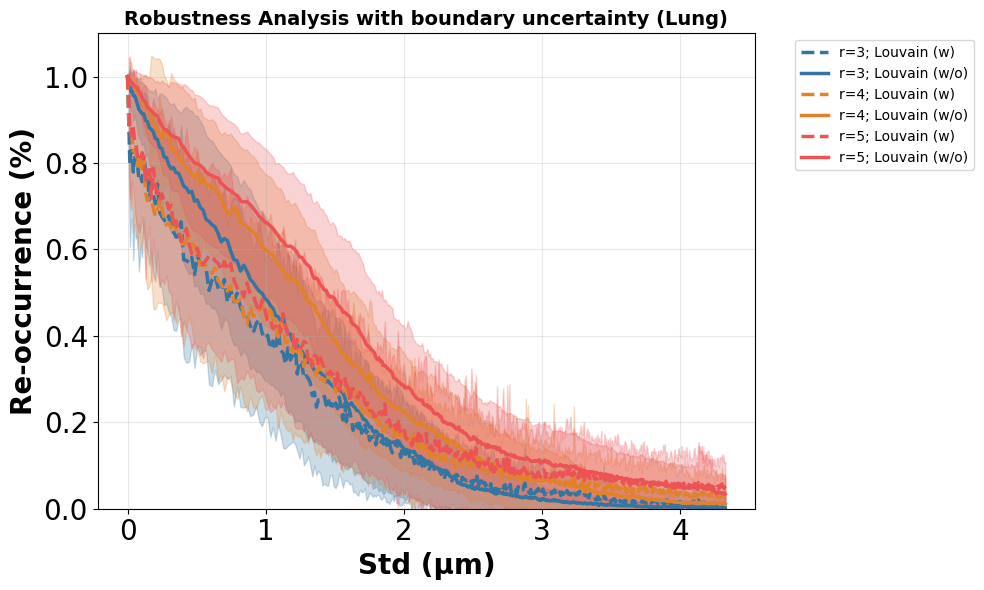

In [21]:
plot_robustness_seaborn(lung_results_bd_noise_c_3, lung_results_bd_noise_nc_3,  
                        lung_results_bd_noise_c_4, lung_results_bd_noise_nc_4,
                        lung_results_bd_noise_c_5, lung_results_bd_noise_nc_5,
                        title="Robustness Analysis with boundary uncertainty (Lung)", filename="lung_bd_noise", std=0.2)

            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010000            0.783784
2      0.010000            0.795455
3      0.010000            0.954545
4      0.010000            0.591549
...         ...                 ...
24439  4.325252            0.019499
24440  4.325252            0.000000
24441  4.325252            0.000000
24442  4.325252            0.010667
24443  4.325252            0.000000

[24444 rows x 2 columns]
            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010000            0.962963
2      0.010000            0.987654
3      0.010000            0.936170
4      0.010000            1.000000
...         ...                 ...
23996  4.325252            0.000000
23997  4.325252            0.000000
23998  4.325252            0.000000
23999  4.325252            0.000000
24000  4.325252            0.000000

[24001 rows x 2 columns]
            Std  Re_occurrence_rate
0      0.000000            1.000000
1      0.010

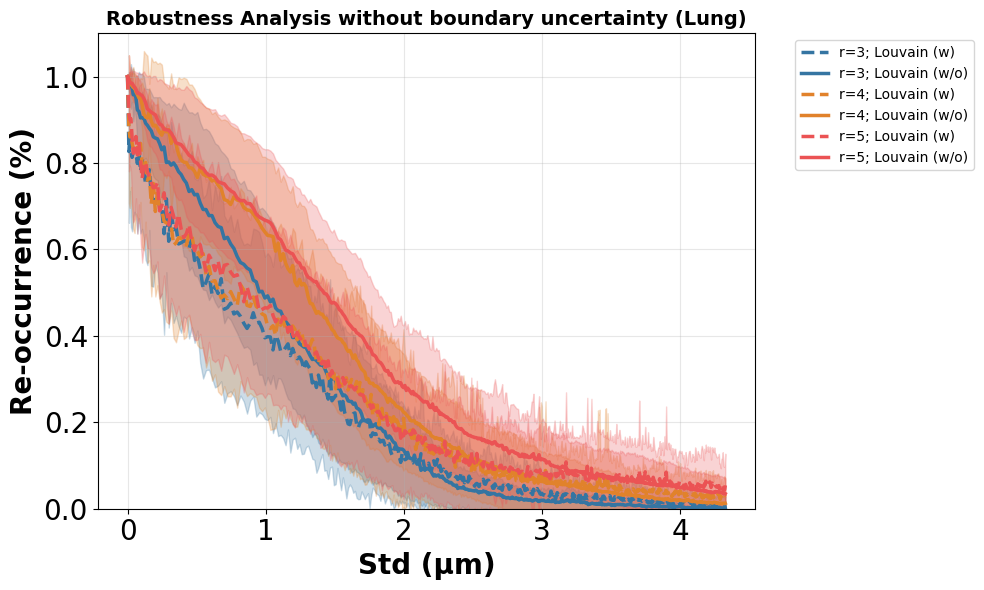

In [20]:
plot_robustness_seaborn(lung_results_nbd_noise_c_3, lung_results_nbd_noise_nc_3,  
                        lung_results_nbd_noise_c_4, lung_results_nbd_noise_nc_4,
                        lung_results_nbd_noise_c_5, lung_results_nbd_noise_nc_5,
                        title="Robustness Analysis without boundary uncertainty (Lung)", filename="lung_nbd_noise", std=0.2)